# 02 — Grating Spectrum with Broad-Line Detection

This notebook demonstrates fitting G395M grating spectra with automatic
BIC-based broad Balmer component detection.

The G395M grating has R ≈ 1000 (constant), resolving [NII]–Hα–[NII] and
[SII] doublets that are blended in the prism.  The broad component fitting
uses `fit_with_broad(mode="auto")` which compares narrow-only vs broad
models via BIC and selects the best one in a single call.

In [1]:
import jwspecfit
import matplotlib.pyplot as plt
import numpy as np

## Second G395M spectrum

In [3]:
spec2 = jwspecfit.read_fits(
    "../../data/stark-rxcj2248-v4_g395m-f290lp_2478_3.spec.fits",
    z=6.1052,
)

result2 = jwspecfit.fit_lines(spec2, z=6.1052, mode="auto",deg=3,n_boot=200,n_boot_bic=0)


print(f"Selected model: {result2.selected_model}")
print(f"χ²/dof = {result2.best_fit.chi2:.2f}")
for name, lr in result2.best_fit.lines.items():
    if lr.snr > 1:
        print(f"  {name:<18s} flux={lr.flux:.2e} ± {lr.flux_err:.2e}  SNR={lr.snr:.1f}")

Bootstrap (broad1): 100%|██████████| 200/200 [00:34<00:00,  5.85iter/s]

Selected model: broad1
χ²/dof = 1.03
  NeIII_3869         flux=3.50e-17 ± 1.92e-17  SNR=1.8
  HEPSILON           flux=5.10e-18 ± 2.86e-18  SNR=1.8
  HGAMMA             flux=5.91e-18 ± 4.93e-18  SNR=1.2
  OIII_4363          flux=6.11e-18 ± 5.76e-18  SNR=1.1
  HEI_4472           flux=9.02e-19 ± 6.34e-19  SNR=1.4
  HeII_4687          flux=5.61e-19 ± 5.47e-19  SNR=1.0
  ArIV_4713          flux=3.51e-19 ± 2.84e-19  SNR=1.2
  HBETA              flux=1.58e-17 ± 7.34e-18  SNR=2.1
  OIII_4959          flux=3.00e-17 ± 1.15e-17  SNR=2.6
  OIII_5007          flux=8.77e-17 ± 1.59e-17  SNR=5.5
  HEI_5877           flux=2.83e-18 ± 1.82e-18  SNR=1.6
  NII_6549           flux=4.07e-19 ± 7.53e-20  SNR=5.4
  Ha                 flux=3.93e-17 ± 1.06e-17  SNR=3.7
  NII_6585           flux=1.21e-18 ± 2.23e-19  SNR=5.4
  HDELTA_BROAD       flux=4.84e-18 ± 2.36e-18  SNR=2.0


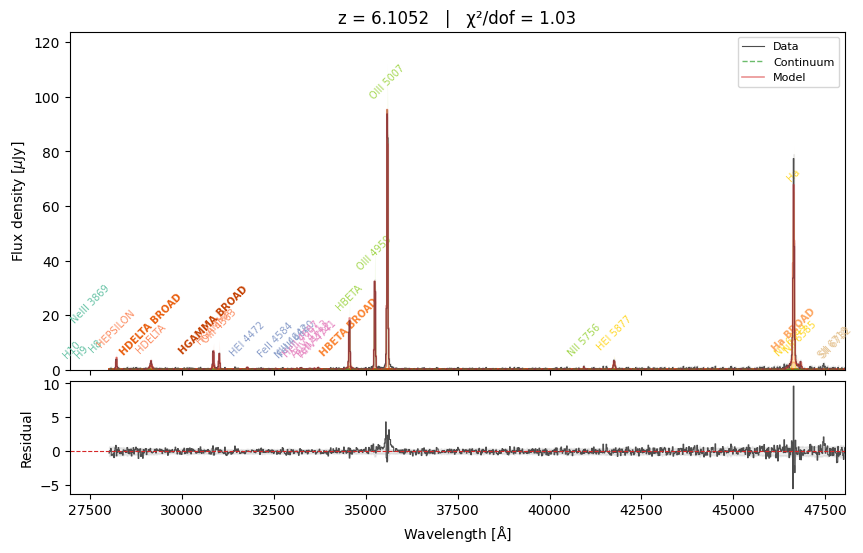

In [5]:
fig = jwspecfit.plot_fit(result2.best_fit,exclude_wave_A=[(20000, 28000),(50000,60000)])
plt.show()

## Interactive plot

Use the plotly interactive plot to zoom into the Hα+[NII] complex
and inspect narrow vs broad components.

In [6]:
fig_interactive = jwspecfit.plot_fit_interactive(result2.best_fit,rest_frame=True)
fig_interactive.show()

## Save results and export line table

In [6]:
# Save the fit result for replotting later
jwspecfit.save_result(result2.best_fit, "g395m_fit_result.npz")

# Export line measurements
jwspecfit.export_lines_txt(result2.best_fit, "g395m_lines.txt")

with open("g395m_lines.txt") as f:
    print(f.read())

# jwspecfit line measurements  z=6.105200
# flux units: erg/s/cm2  |  EW units: rest-frame Angstrom
# name                   rest_A   centroid_A           flux       flux_err       EW_A  sigma_v_kms    SNR_int   SNR_peak
  HDELTA               4104.050    29153.540   1.859017e-18   7.173390e-19     45.637       107.09       2.59       4.21
  HGAMMA               4342.905    30850.269   5.614436e-18   1.206456e-18    134.063       107.09       4.65      10.72
  OIII_4363            4364.436    31009.186   6.203958e-18   7.442979e-19    148.008       125.58       8.34      15.47
  HBETA                4864.041    34552.218   1.558284e-17   1.181797e-18    396.022       107.09      13.19      26.86
  OIII_4959            4961.679    35245.745   3.004871e-17   9.979067e-19    789.321       105.36      30.11      42.33
  OIII_5007            5009.637    35586.471   8.778806e-17   1.077440e-18   2351.490       107.09      81.48      72.37
  NII_5756             5757.787    40934.523   3.9728